# Anomaly Detection

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import sys

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score

sys.path.append('../')
from config import *

## 1. Load Data

In [ ]:
df_full = pd.read_csv(PROCESSED_DIR / "full_windowed.csv")
print(f"Shape of windowed data: {df_full.shape}")

df_normal = pd.read_csv(PROCESSED_DIR / "normal_windowed.csv")
print(f"Shape of normal data: {df_normal.shape}")

df_normal.head()

Shape of windowed data: (1754, 42)
Shape of normal data: (479, 42)


,window_id,dur_mean,dur_std,sbytes_mean,sbytes_std,dbytes_mean,dbytes_std,rate_mean,rate_std,sttl_mean,...,service_ssh_mean,service_ssl_mean,state_CON_mean,state_ECO_mean,state_FIN_mean,state_INT_mean,state_REQ_mean,state_RST_mean,proto_nunique,window_attack
0,0,0.317844,0.383468,6.571681,1.138847,4.251369,3.409974,5.920870,4.008042,189.21,...,0.00,0.0,0.04,0.00,0.60,0.36,0.0,0.0,4,0
1,1,0.272340,0.536134,7.009990,0.916484,3.428353,4.077962,8.423115,3.942508,162.58,...,0.00,0.0,0.08,0.01,0.36,0.55,0.0,0.0,4,0
2,2,0.270119,0.511045,6.097047,1.266632,6.447499,1.852294,6.474863,2.489866,31.00,...,0.01,0.0,0.69,0.00,0.31,0.00,0.0,0.0,2,0
3,3,0.363759,0.534592,6.504552,1.270745,6.984390,1.912316,5.836960,2.809455,31.00,...,0.00,0.0,0.42,0.00,0.58,0.00,0.0,0.0,2,0
4,4,0.664023,0.625825,7.218754,0.761826,7.610472,1.454399,4.008287,2.882684,31.00,...,0.01,0.0,0.07,0.00,0.93,0.00,0.0,0.0,2,0


## 2. Splitting and Scaling data

In [3]:
# Exclude id and label columns
feature_cols = [col for col in df_full.columns 
                if col not in ['window_id', 'window_attack']]

X_train = df_normal[feature_cols]
X_eval = df_full[feature_cols]
y_eval = df_full['window_attack']

print(f"Training set: {X_train.shape}")
print(f"Evaluation set: {X_eval.shape}")

Training set: (479, 40)
Evaluation set: (1754, 40)


In [4]:
# Scale features — fit on normal only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_eval_scaled = scaler.transform(X_eval)

## 3. Model training

In [ ]:
iso = IsolationForest(
    n_estimators=100,
    contamination=0.02, # The expected proportion of outliers
    max_samples='auto', # Samples drawn to build each tree
    random_state=42
)

iso.fit(X_train_scaled)

# Scoring windows
df_full['anomaly_score'] = iso.decision_function(X_eval_scaled) 
# Positive score -> normal (harder to isolate)
# Negative score -> attack (easy to isolate)

df_full['predicted'] = iso.predict(X_eval_scaled)
df_full['predicted_label'] = (df_full['predicted'] == -1).astype(int)

print(f"Anomaly score range: {df_full['anomaly_score'].min():.3f} to {df_full['anomaly_score'].max():.3f}")

Anomaly score range: -0.109 to 0.234


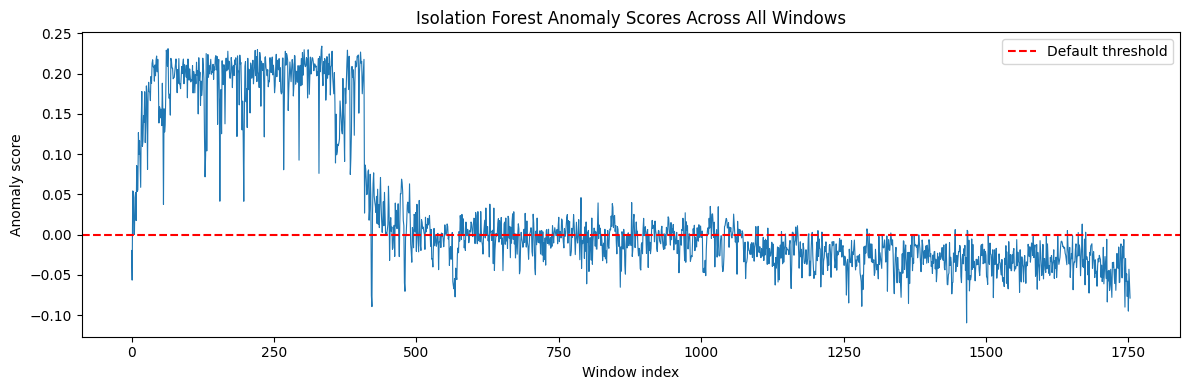

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df_full['anomaly_score'], linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', label='Default threshold')

plt.xlabel('Window index')
plt.ylabel('Anomaly score')
plt.title('Isolation Forest Anomaly Scores Across All Windows')

plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
pure_normal = df_full[df_full['window_attack'] == 0]
pure_attack = df_full[df_full['window_attack'] == 1]

# Exclude transition zone from pure_attack.
# Windows beyond index 1000 are flat at 1.0 attack rate
pure_attack = pure_attack[pure_attack.index > 1000]

print("Normal window scores:")
print(pure_normal['anomaly_score'].describe())

print("\nAttack window scores:")
print(pure_attack['anomaly_score'].describe())

Normal window scores:
count    479.000000
mean       0.160796
std        0.070706
min       -0.089222
25%        0.129942
50%        0.193824
75%        0.210050
max        0.233954
Name: anomaly_score, dtype: float64

Attack window scores:
count    753.000000
mean      -0.027741
std        0.020544
min       -0.109441
25%       -0.040861
50%       -0.027779
75%       -0.013643
max        0.035096
Name: anomaly_score, dtype: float64


## 4. Threshold Tuning
#### Default threshold (0) is weak for identifying window attack

In [8]:
# Finding best threshold
eval_set = pd.concat([pure_normal, pure_attack])
thresholds = np.linspace(-0.09, 0.25, 200)
results = []

for t in thresholds:
    preds = (eval_set['anomaly_score'] < t).astype(int)
    f1 = f1_score(eval_set['window_attack'], preds)
    results.append((t, f1))

best_threshold, best_f1 = max(results, key=lambda x: x[1])
print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1: {best_f1:.4f}")

Best threshold: 0.0262
Best F1: 0.9741


## Parameter Sensitivity Analysis
#### Grid search showed minimal variance (F1 range: 0.9635–0.9663).
#### Current configuration (n=100, auto) is retained as it balances performance and computational efficiency.

In [ ]:
results = []

for n in [50, 100, 200, 300]:
    for samples in [64, 128, 256, 'auto']:
        iso_test = IsolationForest(
            n_estimators=n,
            max_samples=samples,
            contamination=0.02,
            random_state=42
        )
        iso_test.fit(X_train_scaled)
        scores = iso_test.decision_function(X_eval_scaled)

        thresholds = np.linspace(scores.min(), scores.max(), 200)

        best_f1_test = max(f1_score(eval_set['window_attack'],
                     (scores[:len(eval_set)] < t).astype(int))
                     for t in thresholds)
        
        results.append({
            'n_estimators': n,
            'max_samples': samples,
            'best_f1_test': round(best_f1_test, 4)
        })

results_df = pd.DataFrame(results).sort_values('best_f1_test', ascending=False)
print(results_df.head(10))

## 5. Evaluation results

In [10]:
eval_set['tuned_pred'] = (eval_set['anomaly_score'] < best_threshold).astype(int)
print(classification_report(eval_set['window_attack'], eval_set['tuned_pred']))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96       479
           1       0.95      1.00      0.97       753

    accuracy                           0.97      1232
   macro avg       0.97      0.96      0.97      1232
weighted avg       0.97      0.97      0.97      1232



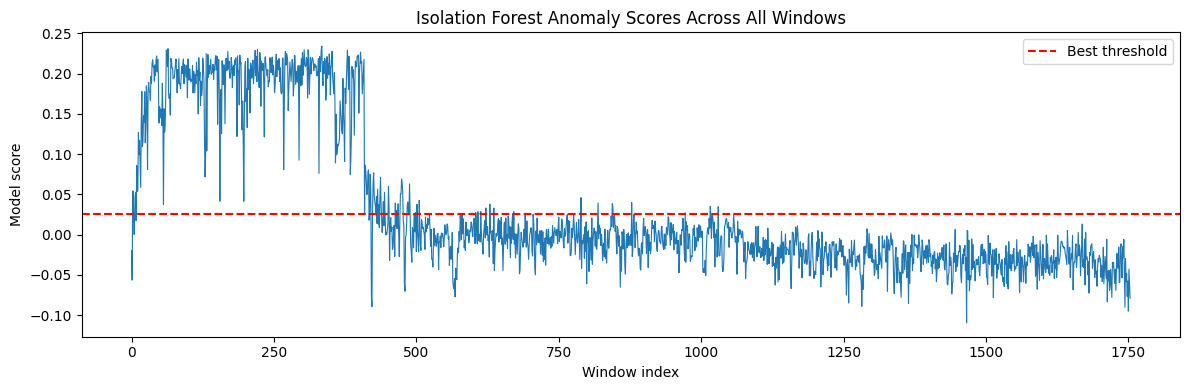

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df_full['anomaly_score'], linewidth=0.8)
plt.axhline(y=best_threshold, color='red', linestyle='--', label='Best threshold')

plt.xlabel('Window index')
plt.ylabel('Model score')
plt.title('Isolation Forest Anomaly Scores Across All Windows')

plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "anomaly_scores.png", dpi=300, bbox_inches='tight')

plt.show()

## 6. Isolating False Positives
#### False Positives — normal windows flagged as attack
#### False Negatives — attack windows missed

In [12]:
# False positives
fp_windows = eval_set[
    (eval_set['window_attack'] == 0) & (eval_set['tuned_pred'] == 1)
]

# False negatives
fn_windows = eval_set[
    (eval_set['window_attack'] == 1) & (eval_set['tuned_pred'] == 0)
]

print(f"False Positives: {len(fp_windows)}")
print(f"False Negatives: {len(fn_windows)}")

False Positives: 38
False Negatives: 2


## 7. Saving
- Model
- Scaler
- False positives and negatives
- Evaluation results

In [ ]:
joblib.dump(scaler, MODEL_DIR / 'scaler.pkl')
joblib.dump(iso, MODEL_DIR / 'isolation_forest.pkl')

fp_windows.to_csv(PROCESSED_DIR / 'fp_windows.csv', index=True)
fn_windows.to_csv(PROCESSED_DIR / 'fn_windows.csv', index=True)
eval_set.to_csv(PROCESSED_DIR / 'eval_results.csv', index=True)

## Summary

In [14]:
print("\n=== Isolation Forest Results ===\n")

print(f"Training windows (normal only): {len(X_train)}")
print(f"Evaluation windows (excl. transition): {len(eval_set)}")

print(f"\nBest threshold: {best_threshold:.4f}")
print(f"Best F1: {best_f1:.4f}")

print(f"\nFalse Positives: {len(fp_windows)}")
print(f"False Negatives: {len(fn_windows)}")


=== Isolation Forest Results ===

Training windows (normal only): 479
Evaluation windows (excl. transition): 1232

Best threshold: 0.0262
Best F1: 0.9741

False Positives: 38
False Negatives: 2
